<a href="https://colab.research.google.com/github/aryanranga721-ops/Celebal_Internship/blob/main/Week3_Aryan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import silhouette_score, classification_report, accuracy_score, confusion_matrix

# Configuration Setup
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

#Data Loading and Exploration

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohan0301/unsupervised-learning-on-country-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'unsupervised-learning-on-country-data' dataset.
Path to dataset files: /kaggle/input/unsupervised-learning-on-country-data


In [ ]:
import os
os.listdir('/kaggle/input/unsupervised-learning-on-country-data')

['Country-data.csv', 'data-dictionary.csv']

In [ ]:
df = pd.read_csv('/kaggle/input/unsupervised-learning-on-country-data/Country-data.csv')
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [ ]:
df.shape

(167, 10)

In [ ]:
df.info

<bound method DataFrame.info of                  country  child_mort  exports  health  imports  income  \
0            Afghanistan        90.2     10.0    7.58     44.9    1610   
1                Albania        16.6     28.0    6.55     48.6    9930   
2                Algeria        27.3     38.4    4.17     31.4   12900   
3                 Angola       119.0     62.3    2.85     42.9    5900   
4    Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   
..                   ...         ...      ...     ...      ...     ...   
162              Vanuatu        29.2     46.6    5.25     52.7    2950   
163            Venezuela        17.1     28.5    4.91     17.6   16500   
164              Vietnam        23.3     72.0    6.84     80.2    4490   
165                Yemen        56.3     30.0    5.18     34.4    4480   
166               Zambia        83.1     37.0    5.89     30.9    3280   

     inflation  life_expec  total_fer   gdpp  
0         9.44        56.2       5.82    553  
1         4.49        76.3       1.65   4090  
2        16.10        76.5       2.89   4460  
3        22.40        60.1       6.16   3530  
4         1.44        76.8       2.13  12200  
..         ...         ...        ...    ...  
162       2.62        63.0       3.50   2970  
163      45.90        75.4       2.47  13500  
164      12.10        73.1       1.95   1310  
165      23.60        67.5       4.67   1310  
166      14.00        52.0       5.40   1460  

[167 rows x 10 columns]>

In [ ]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [ ]:
df.duplicated().sum()

np.int64(0)

#Data Preprocessing and Feature Scaling

In [ ]:
# Drop non-numeric identifier ('country') for clustering and prediction features
X_raw = df.drop(columns=['country'])

# Scale features to have a mean of 0 and variance of 1 (Crucial for distance-based clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Convert back to DataFrame for easier manipulation later
X_scaled_df = pd.DataFrame(X_scaled, columns=X_raw.columns)
print("Data preprocessed and scaled successfully. Shape:", X_scaled_df.shape)
X_scaled_df.head()

Data preprocessed and scaled successfully. Shape: (167, 9)


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


#K-Means Clustering for Customer Segmentation

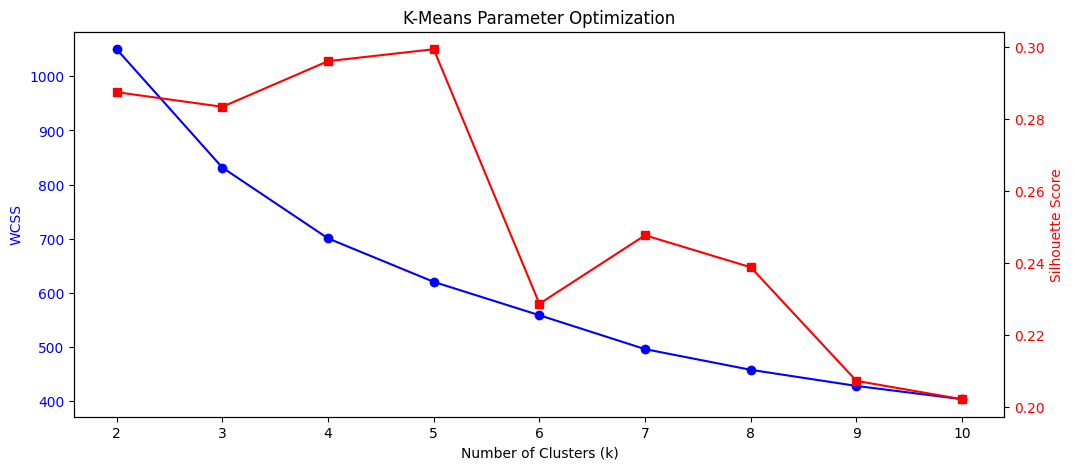

KMeans_Labels
2    84
1    47
0    36
Name: count, dtype: int64


In [ ]:
# Determine optimal clusters using the Elbow Method
wcss = []
silhouette_scores = []
cluster_range = range(2, 11)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow and Silhouette analysis
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(cluster_range, wcss, color='blue', marker='o', label='WCSS (Elbow)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(cluster_range, silhouette_scores, color='red', marker='s', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('K-Means Parameter Optimization')
plt.show()

# Selecting k=3 based on dataset characteristics (Under-developed, Developing, Developed)
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_final.fit(X_scaled)
df['KMeans_Labels'] = kmeans_final.labels_
print(df['KMeans_Labels'].value_counts())

#Density-Based Clustering

DBSCAN Cluster Distribution (-1 represents noise/outliers):
DBSCAN_Labels
 0    156
-1     11
Name: count, dtype: int64


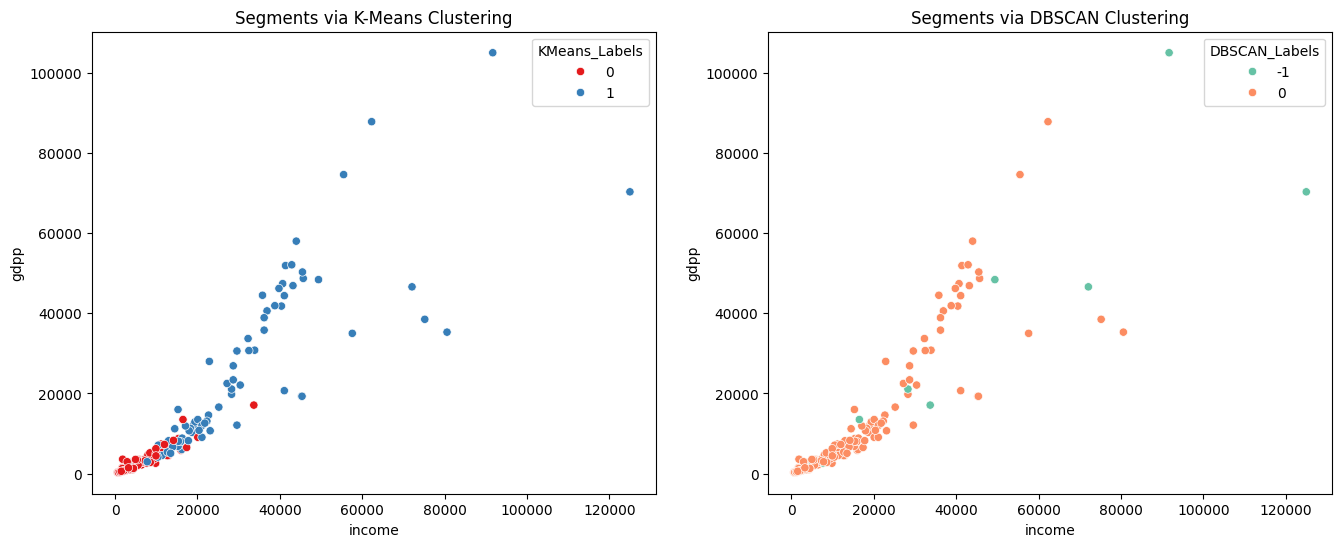

In [ ]:
# Initialize and fit DBSCAN to identify core customer groups and potential outliers (noise)
# Tuning eps and min_samples for continuous space density assessment
dbscan = DBSCAN(eps=2.0, min_samples=3)
df['DBSCAN_Labels'] = dbscan.fit_predict(X_scaled)

print("DBSCAN Cluster Distribution (-1 represents noise/outliers):")
print(df['DBSCAN_Labels'].value_counts())

# Visualize K-Means vs DBSCAN groupings based on Income vs GDPP
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df, x='income', y='gdpp', hue='KMeans_Labels', palette='Set1', ax=ax1)
ax1.set_title('Segments via K-Means Clustering')

sns.scatterplot(data=df, x='income', y='gdpp', hue='DBSCAN_Labels', palette='Set2', ax=ax2)
ax2.set_title('Segments via DBSCAN Clustering')

plt.show()

#Classification with Ensemble Learning - Random Forest Classifier

=== Random Forest Performance ===
              precision    recall  f1-score   support

           0       0.88      1.00      0.94        23
           1       1.00      0.84      0.91        19

    accuracy                           0.93        42
   macro avg       0.94      0.92      0.93        42
weighted avg       0.94      0.93      0.93        42



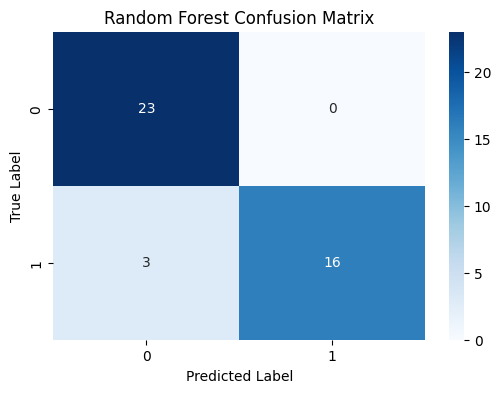

In [ ]:
# Setup features and target (using KMeans labels as the target class for predictive mapping)
X = X_raw.copy()
y = df['KMeans_Labels']

# Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Instantiate and Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict and Evaluate
y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest Performance ===")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#Advanced Ensemble Learning - XGBoost Classifier and Actionable Insights

=== XGBoost Performance ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        19

    accuracy                           1.00        42
   macro avg       1.00      1.00      1.00        42
weighted avg       1.00      1.00      1.00        42



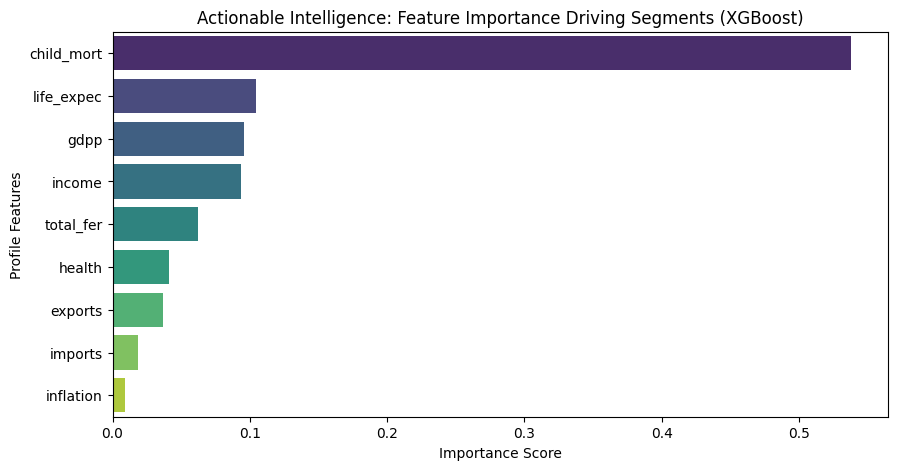


Top Predictors driving customer profiling segments:
      Feature  Importance
0  child_mort    0.537696
6  life_expec    0.104263
8        gdpp    0.095869
4      income    0.093824
7   total_fer    0.061982
2      health    0.041486
1     exports    0.036979
3     imports    0.018471
5   inflation    0.009430


In [ ]:
# Instantiate and Train XGBoost Classifier
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)

# Predict and Evaluate
y_pred_xgb = xgb_model.predict(X_test)

print("=== XGBoost Performance ===")
print(classification_report(y_test, y_pred_xgb))

# Feature Importance Mapping for Actionable Insights
importances = xgb_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Actionable Intelligence: Feature Importance Driving Segments (XGBoost)')
plt.xlabel('Importance Score')
plt.ylabel('Profile Features')
plt.show()

print("\nTop Predictors driving customer profiling segments:")
print(feature_imp_df)

#Conclusion:

This end-to-end solution effectively illustrates how a highly reliable consumer intelligence pipeline may be created by fusing supervised ensemble learning with unsupervised behavioral profiling.
